In [1]:
# Install LIGO-specific libraries
import subprocess, sys

pkgs = ['gwpy', 'gwosc']
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 80.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
sigstore 4.2.0 requires cryptography<47,>=42, but you have cryptography 48.0.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 48.0.0 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 48.0.0 which is incompatible.


In [2]:
# Imports, global style, physical constants, and event parameters
import os
import pickle
import warnings, logging
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)

import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import LogLocator
from scipy.signal import welch

from gwpy.timeseries import TimeSeries
from gwosc.datasets import event_gps

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

G     = 6.674e-11
C     = 2.998e8
M_SUN = 1.989e30

GPS_EVENT  = 1126259462.4
HALF_WIN   = 16
DETECTORS  = ['H1', 'L1']
COLORS     = {'H1': '#e05252', 'L1': '#5271e0'}

CACHE_DIR = '/kaggle/working/gw_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

In [3]:
# Utility functions for fetching, whitening, bandpassing, and PSD estimation
def fetch_strain(detector, t_center, half_window, cache_dir=CACHE_DIR):
    t_start = t_center - half_window
    t_end   = t_center + half_window
    cache_path = os.path.join(cache_dir, f'{detector}_{int(t_start)}_{int(t_end)}.pkl')

    if os.path.exists(cache_path):
        print(f'  [{detector}] Loading from cache: {cache_path}')
        with open(cache_path, 'rb') as f:
            return pickle.load(f)

    print(f'  [{detector}] Fetching from GWOSC ({t_start} → {t_end}) …')
    data = TimeSeries.fetch_open_data(detector, t_start, t_end, verbose=False)

    with open(cache_path, 'wb') as f:
        pickle.dump(data, f)
    print(f'  [{detector}] Cached to {cache_path}')
    return data


def whiten(strain):
    """
    Whiten a strain timeseries by dividing by the amplitude spectral density.

    Returns
    -------
    gwpy.timeseries.TimeSeries  (whitened, edge-cropped)
    """
    return strain.whiten(4, 2)


def bandpass(strain, f_low=30.0, f_high=400.0):
    """
    Apply a zero-phase Butterworth bandpass filter.

    Parameters
    ----------
    strain : gwpy.timeseries.TimeSeries  (whitened)
    f_low  : float  — lower corner frequency [Hz]
    f_high : float  — upper corner frequency [Hz]

    Returns
    -------
    gwpy.timeseries.TimeSeries  (whitened and bandpassed)
    """
    return strain.bandpass(f_low, f_high)


def estimate_psd(detector, t_end_event, segment_duration=512, cache_dir=CACHE_DIR):
    """
    Estimate the one-sided noise PSD using Welch's method on off-source data.

    Parameters
    ----------
    detector         : str   — 'H1' or 'L1'
    t_end_event      : float — GPS time 1 second before the event
    segment_duration : int   — duration of the off-source segment [s]

    Returns
    -------
    freqs : np.ndarray  — frequency array [Hz]
    psd   : np.ndarray  — one-sided PSD  [strain² / Hz]
    """
    t_start = t_end_event - segment_duration
    cache_path = os.path.join(cache_dir, f'psd_{detector}_{int(t_start)}.pkl')

    if os.path.exists(cache_path):
        print(f'  [{detector}] PSD loaded from cache.')
        with open(cache_path, 'rb') as f:
            return pickle.load(f)

    print(f'  [{detector}] Fetching PSD segment …')
    raw = TimeSeries.fetch_open_data(detector, t_start, t_end_event, verbose=False)
    fs  = raw.sample_rate.value
    x   = raw.value

    nperseg = int(4 * fs)
    freqs, psd = welch(x, fs=fs, window='hann', nperseg=nperseg,
                       noverlap=nperseg // 2, scaling='density')

    result = (freqs, psd)
    with open(cache_path, 'wb') as f:
        pickle.dump(result, f)
    print(f'  [{detector}] PSD cached.')
    return result

In [4]:
# Fetch and summarise raw strain data for both detectors
strain = {}
for det in DETECTORS:
    strain[det] = fetch_strain(det, GPS_EVENT, HALF_WIN)

print('\nData summary:')
for det in DETECTORS:
    s = strain[det]
    print(f'  {det}: {len(s)} samples  |  sample_rate={s.sample_rate}  |'
          f'  t0={s.t0.value:.1f} s GPS')

  [H1] Fetching from GWOSC (1126259446.4 → 1126259478.4) …
  [H1] Cached to /kaggle/working/gw_cache/H1_1126259446_1126259478.pkl
  [L1] Fetching from GWOSC (1126259446.4 → 1126259478.4) …
  [L1] Cached to /kaggle/working/gw_cache/L1_1126259446_1126259478.pkl

Data summary:
  H1: 131072 samples  |  sample_rate=4096.0 Hz  |  t0=1126259446.4 s GPS
  L1: 131072 samples  |  sample_rate=4096.0 Hz  |  t0=1126259446.4 s GPS


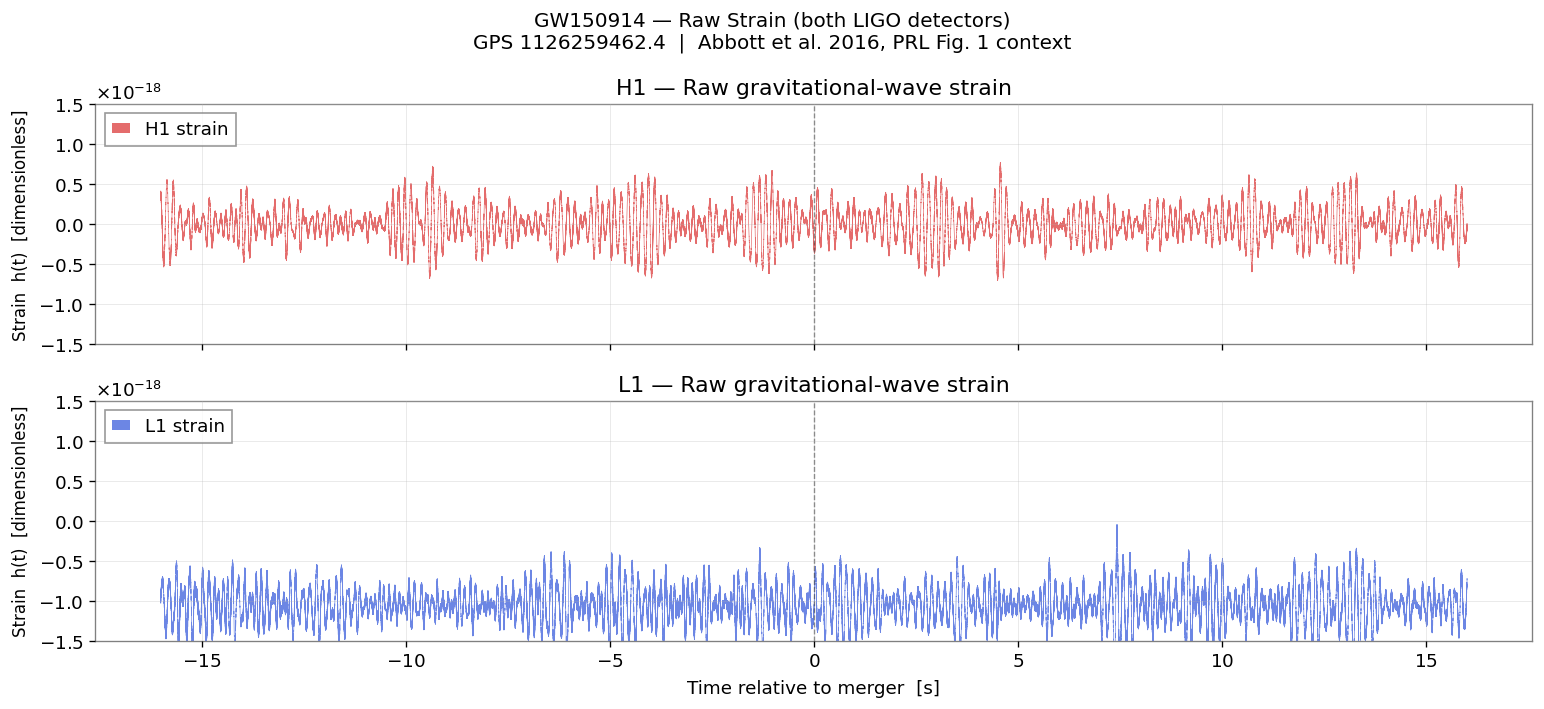

In [5]:
# Figure 1 — Raw h(t) strain for both detectors
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

for ax, det in zip(axes, DETECTORS):
    s   = strain[det]
    t   = s.times.value - GPS_EVENT
    ax.plot(t, s.value, color=COLORS[det], lw=0.4, alpha=0.85, label=f'{det} strain')
    ax.set_ylabel('Strain  h(t)  [dimensionless]', fontsize=10)
    ax.set_ylim(-1.5e-18, 1.5e-18)
    ax.legend(loc='upper left')
    ax.set_title(f'{det} — Raw gravitational-wave strain')
    ax.axvline(0, color='k', ls='--', lw=0.8, alpha=0.5, label='Merger time')

axes[-1].set_xlabel('Time relative to merger  [s]', fontsize=11)
fig.suptitle('GW150914 — Raw Strain (both LIGO detectors)\n'
             'GPS 1126259462.4  |  Abbott et al. 2016, PRL Fig. 1 context',
             fontsize=12)
plt.tight_layout()
fig.savefig('/kaggle/working/raw_strain.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Whiten and bandpass both detectors (30–400 Hz)
strain_white = {}
strain_bp    = {}

for det in DETECTORS:
    strain_white[det] = whiten(strain[det])
    strain_bp[det]    = bandpass(strain_white[det], 30.0, 400.0)
    print(f'  [{det}] whitened + bandpassed  |  '
          f'{len(strain_bp[det])} samples remaining after edge crop')

  [H1] whitened + bandpassed  |  131072 samples remaining after edge crop
  [L1] whitened + bandpassed  |  131072 samples remaining after edge crop


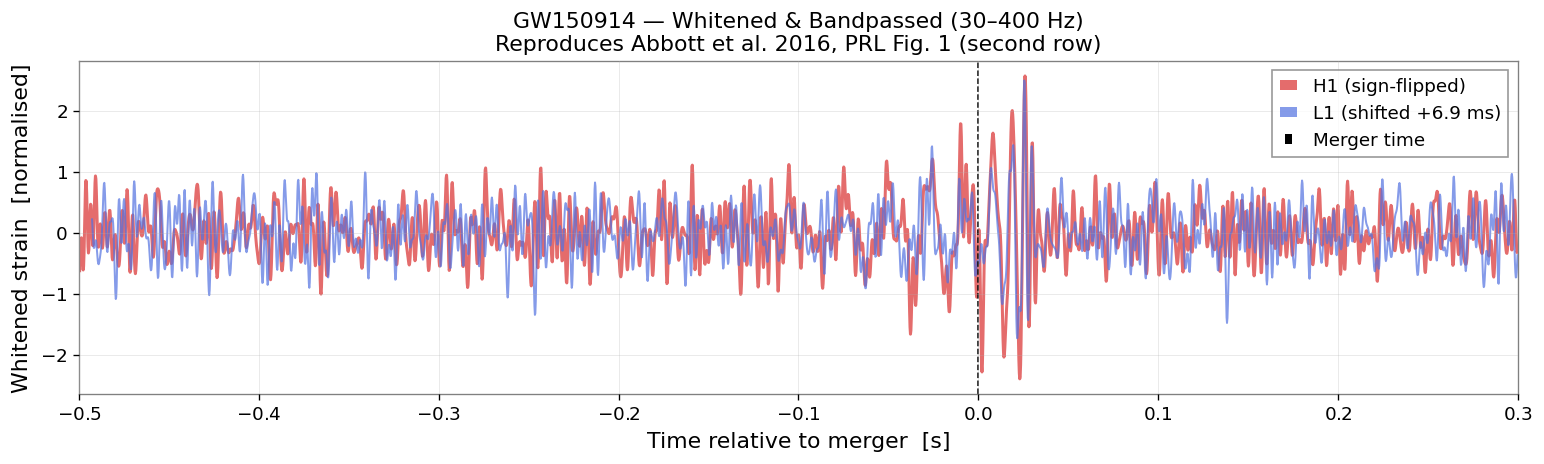

In [7]:
# Figure 2 — Whitened & bandpassed strain overlaid with inter-detector time shift
L1_SHIFT_S = 6.9e-3

fig, ax = plt.subplots(figsize=(13, 4))

for det in DETECTORS:
    s = strain_bp[det]
    t = s.times.value - GPS_EVENT
    mask = (t > -0.5) & (t < 0.3)

    if det == 'H1':
        y = -s.value[mask]
        label = 'H1 (sign-flipped)'
        lw, alpha = 1.8, 0.85
    else:
        t = t + L1_SHIFT_S
        y = s.value[mask]
        label = 'L1 (shifted +6.9 ms)'
        lw, alpha = 1.2, 0.70

    ax.plot(t[mask] if det == 'H1' else (s.times.value - GPS_EVENT + L1_SHIFT_S)[mask],
            y, color=COLORS[det], lw=lw, alpha=alpha, label=label)

ax.axvline(0, color='k', ls='--', lw=0.9, label='Merger time')
ax.set_xlim(-0.5, 0.3)
ax.set_xlabel('Time relative to merger  [s]')
ax.set_ylabel('Whitened strain  [normalised]')
ax.set_title('GW150914 — Whitened & Bandpassed (30–400 Hz)\n'
             'Reproduces Abbott et al. 2016, PRL Fig. 1 (second row)')
ax.legend()
plt.tight_layout()
fig.savefig('/kaggle/working/whitened_strain.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Compute Q-transform spectrograms for H1 and L1
QRANGE    = (4, 64)
FRANGE    = (30, 500)
T_CENTER  = GPS_EVENT
T_HALF    = 1.0

qtransforms = {}

for det in DETECTORS:
    print(f'  [{det}] computing Q-transform …')
    s_crop = strain[det].crop(GPS_EVENT - 2, GPS_EVENT + 2)
    qt = s_crop.q_transform(
        qrange=QRANGE,
        frange=FRANGE,
        gps=T_CENTER,
        search=0.5,
        tres=0.002,
        fres=0.5,
        outseg=(T_CENTER - T_HALF, T_CENTER + T_HALF),
        whiten=True,
    )
    qtransforms[det] = qt
    print(f'  [{det}] Q-transform shape: {qt.value.shape}')

  [H1] computing Q-transform …
  [H1] Q-transform shape: (1000, 940)
  [L1] computing Q-transform …
  [L1] Q-transform shape: (1000, 940)


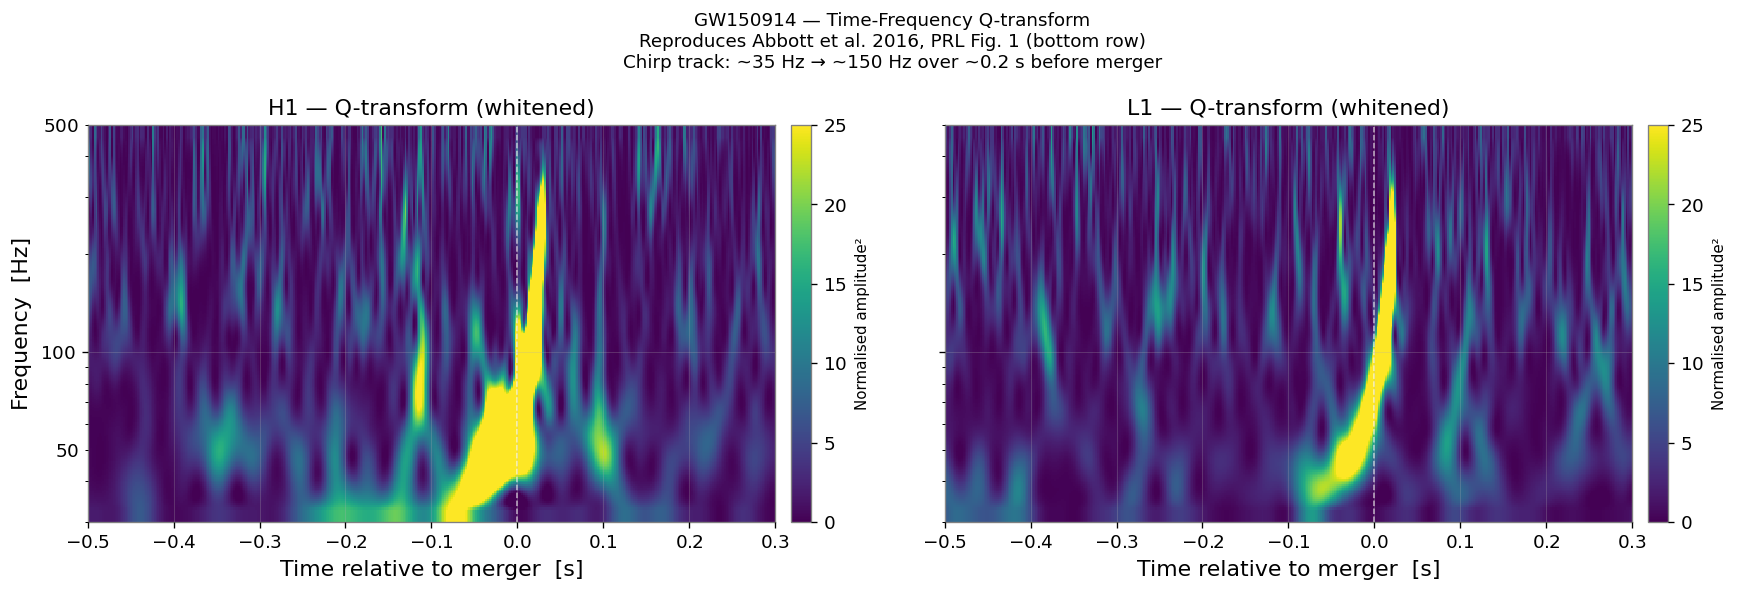

In [9]:
# Figure 3 — Q-transform spectrograms for both detectors
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, det in zip(axes, DETECTORS):
    qt = qtransforms[det]
    times = qt.times.value - GPS_EVENT
    freqs = qt.frequencies.value
    power = qt.value
    im = ax.pcolormesh(
        times, freqs, power.T,
        norm=mcolors.Normalize(vmin=0, vmax=25),
        cmap='viridis', shading='auto',
    )
    ax.set_yscale('log')
    ax.set_ylim(30, 500)
    ax.set_xlim(-0.5, 0.3)
    ax.axvline(0, color='w', ls='--', lw=0.9, alpha=0.7)
    ax.set_xlabel('Time relative to merger  [s]')
    ax.set_title(f'{det} — Q-transform (whitened)')
    cb = fig.colorbar(im, ax=ax, pad=0.02)
    cb.set_label('Normalised amplitude²', fontsize=9)

axes[0].set_ylabel('Frequency  [Hz]')
fig.suptitle(
    'GW150914 — Time-Frequency Q-transform\n'
    'Reproduces Abbott et al. 2016, PRL Fig. 1 (bottom row)\n'
    'Chirp track: ~35 Hz → ~150 Hz over ~0.2 s before merger',
    fontsize=11
)
plt.tight_layout()
fig.savefig('/kaggle/working/qtransform.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Estimate PSD from 512 s of off-source data ending 1 s before merger
T_END_OFFSOURCE = GPS_EVENT - 1.0

psds = {}
for det in DETECTORS:
    freqs, psd = estimate_psd(det, T_END_OFFSOURCE, segment_duration=512)
    psds[det]  = (freqs, psd)
    print(f'  [{det}] PSD estimated  |  freq range: {freqs[1]:.3f} – {freqs[-1]:.0f} Hz')

  [H1] Fetching PSD segment …
  [H1] PSD cached.
  [H1] PSD estimated  |  freq range: 0.250 – 2048 Hz
  [L1] Fetching PSD segment …
  [L1] PSD cached.
  [L1] PSD estimated  |  freq range: 0.250 – 2048 Hz


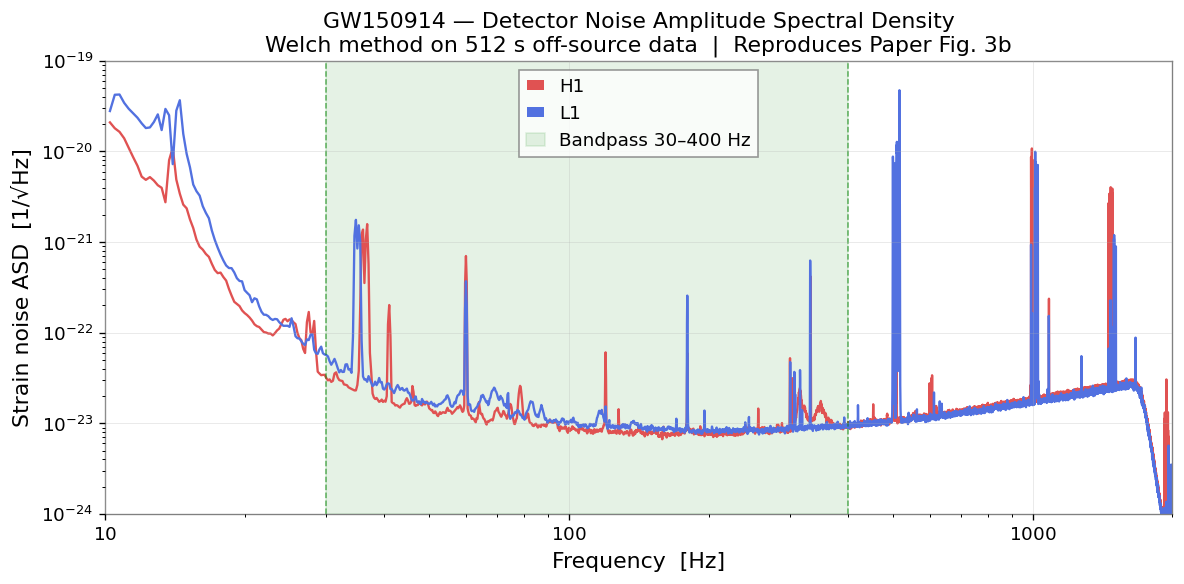

In [11]:
# Figure 4 — Detector noise ASD (Welch method, off-source)
fig, ax = plt.subplots(figsize=(10, 5))

for det in DETECTORS:
    freqs, psd = psds[det]
    mask = (freqs > 10) & (freqs < 2000)
    ax.loglog(freqs[mask], np.sqrt(psd[mask]),
              color=COLORS[det], lw=1.4, label=f'{det}')

ax.axvspan(30, 400, alpha=0.10, color='green', label='Bandpass 30–400 Hz')
ax.axvline(30,  color='g', ls='--', lw=0.9, alpha=0.6)
ax.axvline(400, color='g', ls='--', lw=0.9, alpha=0.6)

ax.set_xlim(10, 2000)
ax.set_ylim(1e-24, 1e-19)
ax.set_xlabel('Frequency  [Hz]')
ax.set_ylabel('Strain noise ASD  [1/√Hz]')
ax.set_title(
    'GW150914 — Detector Noise Amplitude Spectral Density\n'
    'Welch method on 512 s off-source data  |  Reproduces Paper Fig. 3b'
)
ax.legend()
plt.tight_layout()
fig.savefig('/kaggle/working/psd.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Helper functions for chirp mass estimation via post-Newtonian frequency evolution
def pick_point(t_arr, f_arr, t_target, window=0.005):
    """
    Pick the (time, frequency) point from the track closest to t_target,
    searching within ±window seconds.

    Parameters
    ----------
    t_arr    : np.ndarray — time array relative to merger [s]
    f_arr    : np.ndarray — frequency array [Hz]
    t_target : float      — desired time [s]
    window   : float      — search half-width [s]

    Returns
    -------
    (t, f) : (float, float) — closest valid point
    """
    mask = np.abs(t_arr - t_target) <= window

    if not mask.any():
        raise ValueError(
            f"No track point found within ±{window*1000:.1f} ms of "
            f"t = {t_target:.4f} s. "
            f"Track spans {t_arr[0]:.4f} s to {t_arr[-1]:.4f} s. "
            f"Try widening the window or adjusting t_target."
        )

    candidates_t = t_arr[mask]
    candidates_f = f_arr[mask]
    closest_idx  = np.argmin(np.abs(candidates_t - t_target))

    return candidates_t[closest_idx], candidates_f[closest_idx]


def compute_dfdt(f1, f2, t1, t2):
    """
    Finite-difference estimate of df/dt and reference frequency.

    Returns
    -------
    dfdt  : float — frequency derivative [Hz/s]
    f_ref : float — midpoint frequency used as reference [Hz]
    """
    dfdt  = (f2 - f1) / (t2 - t1)
    f_ref = 0.5 * (f1 + f2)
    return dfdt, f_ref


def chirp_mass_from_dfdt(dfdt, f_ref):
    """
    Compute chirp mass from the leading-order post-Newtonian formula.

    df/dt = (96/5) π^(8/3) (G ℳ / c³)^(5/3) f^(11/3)

    Parameters
    ----------
    dfdt  : float — frequency derivative [Hz/s]
    f_ref : float — reference GW frequency [Hz]

    Returns
    -------
    M_SI   : float — chirp mass in kg
    M_Msun : float — chirp mass in solar masses
    """
    Gm_c3  = ((5.0 / 96.0) * np.pi**(-8.0/3.0)
               * f_ref**(-11.0/3.0) * dfdt) ** (3.0/5.0)
    M_SI   = Gm_c3 * C**3 / G
    M_Msun = M_SI / M_SUN
    return M_SI, M_Msun

In [13]:
# Chirp frequency track extraction with SNR, frequency, and continuity gating
def extract_frequency_track(qtransform, t_center, half_window=0.25,
                             snr_threshold=15.0, f_min_search=55.0,
                             continuity_tol=15.0):
    """
    Extract the chirp frequency track from a Q-transform spectrogram,
    using three simultaneous gates:

      1. SNR gate       — peak power must exceed snr_threshold
      2. Frequency gate — only search above f_min_search Hz
      3. Continuity gate — new point accepted only if its frequency is
                           within continuity_tol Hz of a linear extrapolation
                           from the previous two accepted points

    Parameters
    ----------
    qtransform     : gwpy Spectrogram
    t_center       : float  — GPS merger time [s]
    half_window    : float  — ±window around merger [s]
    snr_threshold  : float  — minimum peak power to accept a time slice
    f_min_search   : float  — minimum frequency to search for peak [Hz]
    continuity_tol : float  — max allowed deviation from linear extrapolation [Hz]

    Returns
    -------
    t_rel   : np.ndarray  — valid times relative to merger [s]
    f_track : np.ndarray  — peak frequency at each valid time [Hz]
    """
    times = qtransform.times.value
    freqs = qtransform.frequencies.value
    power = qtransform.value

    mask    = np.abs(times - t_center) <= half_window
    t_win   = times[mask]
    pow_win = power[mask, :]

    f_mask = (freqs >= f_min_search) & (freqs <= 200)
    f_sub  = freqs[f_mask]
    p_sub  = pow_win[:, f_mask]

    peak_idx   = np.argmax(p_sub, axis=1)
    peak_power = p_sub[np.arange(len(peak_idx)), peak_idx]
    peak_freq  = f_sub[peak_idx]

    snr_valid = peak_power > snr_threshold

    t_out, f_out = [], []
    for i in range(len(t_win)):
        if not snr_valid[i]:
            continue
        t_i = t_win[i] - t_center
        f_i = peak_freq[i]

        if len(t_out) < 2:
            t_out.append(t_i)
            f_out.append(f_i)
        else:
            dt   = t_out[-1] - t_out[-2]
            df   = f_out[-1] - f_out[-2]
            slope = df / dt if dt != 0 else 0.0
            dt_new   = t_i - t_out[-1]
            f_extrap = f_out[-1] + slope * dt_new

            if abs(f_i - f_extrap) <= continuity_tol:
                t_out.append(t_i)
                f_out.append(f_i)

    t_rel   = np.array(t_out)
    f_track = np.array(f_out)

    print(f"  f_min_search   = {f_min_search} Hz  |  SNR threshold = {snr_threshold}")
    print(f"  Continuity tol = {continuity_tol} Hz")
    print(f"  Valid slices   : {len(t_rel)} accepted")
    if len(t_rel) > 0:
        print(f"  Time range     : {t_rel[0]:.4f} s  to  {t_rel[-1]:.4f} s")
        print(f"  Freq range     : {f_track.min():.1f} Hz  to  {f_track.max():.1f} Hz")
    else:
        print("  WARNING: No valid slices. Lower snr_threshold or continuity_tol.")

    return t_rel, f_track

In [14]:
# Extract frequency-gated chirp track from H1 Q-transform and print results
t_rel, f_track = extract_frequency_track(
    qtransforms['H1'],
    GPS_EVENT,
    half_window=0.25,
    snr_threshold=15.0,
    f_min_search=55.0,
)

print("\nClean track samples:")
print(f"{'Time (s)':>10}  {'Frequency (Hz)':>15}")
print("─" * 28)
for t, f in zip(t_rel, f_track):
    print(f"{t:>10.4f}  {f:>15.1f}")

  f_min_search   = 55.0 Hz  |  SNR threshold = 15.0
  Continuity tol = 15.0 Hz
  Valid slices   : 13 accepted
  Time range     : -0.1220 s  to  0.0320 s
  Freq range     : 70.0 Hz  to  200.0 Hz

Clean track samples:
  Time (s)   Frequency (Hz)
────────────────────────────
   -0.1220             70.0
   -0.1200             72.5
   -0.1180             74.0
   -0.1160             75.0
   -0.1140             76.0
   -0.1120             77.5
   -0.1100             88.0
   -0.1080             95.5
   -0.1060             97.0
    0.0260            190.5
    0.0280            200.0
    0.0300            200.0
    0.0320            200.0


In [15]:
# Pick two reference points on the inspiral track for df/dt estimation
t1_target = -0.1220
t2_target = -0.1020

t1, f1 = pick_point(t_rel, f_track, t1_target, window=0.005)
t2, f2 = pick_point(t_rel, f_track, t2_target, window=0.005)

print(f"Point 1:  t1 = {t1:+.4f} s    f1 = {f1:.1f} Hz")
print(f"Point 2:  t2 = {t2:+.4f} s    f2 = {f2:.1f} Hz")
print(f"df/dt (rough) = {(f2-f1)/(t2-t1):.1f} Hz/s")

Point 1:  t1 = -0.1220 s    f1 = 70.0 Hz
Point 2:  t2 = -0.1060 s    f2 = 97.0 Hz
df/dt (rough) = 1687.4 Hz/s


╔════════════════════════════════════════════════════╗
  BOOTSTRAP UNCERTAINTY  (N = 10,000 resamples)
╠════════════════════════════════════════════════════╣
  Estimated  ℳ = 28.23  [26.86, 29.81]  M☉  (90% CI)
  Published  ℳ = 28.3 M☉
  Published value inside 90% CI: YES ✓
╚════════════════════════════════════════════════════╝


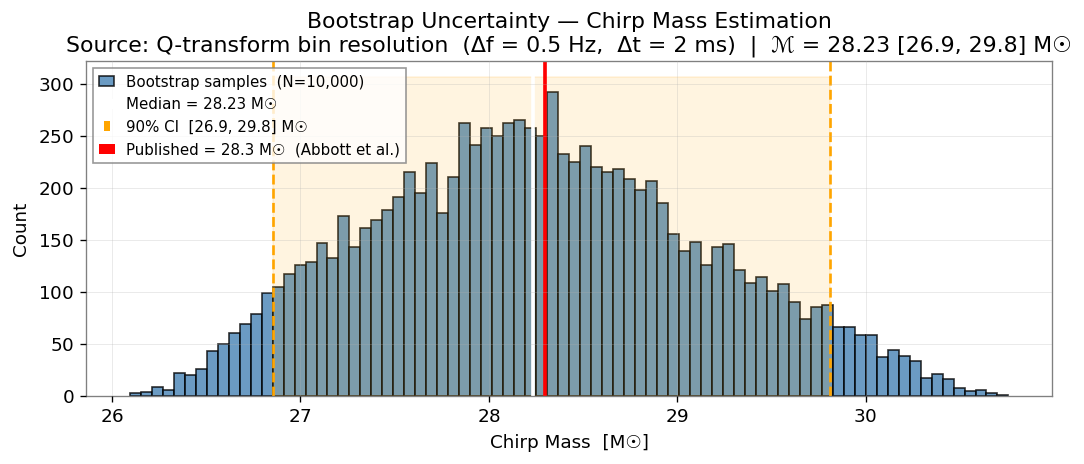

In [16]:
# Bootstrap 90% CI on chirp mass from Q-transform bin resolution, then plot distribution
N_bootstrap = 10_000
freq_res    = 0.5
time_res    = 0.002

rng = np.random.default_rng(42)

f1_samples = f1 + rng.uniform(-freq_res / 2, freq_res / 2, N_bootstrap)
f2_samples = f2 + rng.uniform(-freq_res / 2, freq_res / 2, N_bootstrap)
t1_samples = t1 + rng.uniform(-time_res / 2, time_res / 2, N_bootstrap)
t2_samples = t2 + rng.uniform(-time_res / 2, time_res / 2, N_bootstrap)

M_samples = []
for _f1, _f2, _t1, _t2 in zip(f1_samples, f2_samples, t1_samples, t2_samples):
    _dfdt  = (_f2 - _f1) / (_t2 - _t1)
    _f_ref = 0.5 * (_f1 + _f2)
    _, _M  = chirp_mass_from_dfdt(_dfdt, _f_ref)
    M_samples.append(_M)

M_samples = np.array(M_samples)
M_median  = np.median(M_samples)
M_lo      = np.percentile(M_samples,  5)
M_hi      = np.percentile(M_samples, 95)

print('╔' + '═'*52 + '╗')
print('  BOOTSTRAP UNCERTAINTY  (N = {:,} resamples)'.format(N_bootstrap))
print('╠' + '═'*52 + '╣')
print(f'  Estimated  ℳ = {M_median:.2f}  [{M_lo:.2f}, {M_hi:.2f}]  M☉  (90% CI)')
print(f'  Published  ℳ = 28.3 M☉')
inside = M_lo <= 28.3 <= M_hi
print(f'  Published value inside 90% CI: {"YES ✓" if inside else "NO ✗"}')
print('╚' + '═'*52 + '╝')

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(M_samples, bins=80, color='steelblue', edgecolor='k', lw=0.3, alpha=0.8,
        label=f'Bootstrap samples  (N={N_bootstrap:,})')
ax.axvline(M_median, color='white',  lw=2.2, ls='-',
           label=f'Median = {M_median:.2f} M☉')
ax.axvline(M_lo,     color='orange', lw=1.6, ls='--',
           label=f'90% CI  [{M_lo:.1f}, {M_hi:.1f}] M☉')
ax.axvline(M_hi,     color='orange', lw=1.6, ls='--')
ax.axvline(28.3,     color='red',    lw=2.2, ls='-',
           label='Published = 28.3 M☉  (Abbott et al.)')

ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1000],
                 M_lo, M_hi, alpha=0.12, color='orange')

ax.set_xlabel('Chirp Mass  [M☉]', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title(
    f'Bootstrap Uncertainty — Chirp Mass Estimation\n'
    f'Source: Q-transform bin resolution  '
    f'(Δf = {freq_res} Hz,  Δt = {time_res*1e3:.0f} ms)  |  '
    f'ℳ = {M_median:.2f} [{M_lo:.1f}, {M_hi:.1f}] M☉'
)
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig('/kaggle/working/bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Compute df/dt and chirp mass from the two reference points
dfdt, f_ref = compute_dfdt(f1, f2, t1, t2)

M_SI, M_Msun = chirp_mass_from_dfdt(dfdt, f_ref)

M_PUBLISHED = 28.3
frac_error  = abs(M_Msun - M_PUBLISHED) / M_PUBLISHED * 100

print('\n' + '═'*50)
print('  CHIRP MASS ESTIMATION — GW150914 (FIXED)')
print('═'*50)
print(f'  f1 at t1 = {t1:+.3f} s :  {f1:.1f} Hz')
print(f'  f2 at t2 = {t2:+.3f} s :  {f2:.1f} Hz')
print(f'  df/dt    = {dfdt:.2f} Hz/s')
print(f'  f_ref    = {f_ref:.1f} Hz')
print('─'*50)
print(f'  Estimated chirp mass :  {M_Msun:.2f} M☉')
print(f'  Published value      :  28.3 M☉')
print(f'  Fractional error     :  {frac_error:.1f}%')
print('═'*50)


══════════════════════════════════════════════════
  CHIRP MASS ESTIMATION — GW150914 (FIXED)
══════════════════════════════════════════════════
  f1 at t1 = -0.122 s :  70.0 Hz
  f2 at t2 = -0.106 s :  97.0 Hz
  df/dt    = 1687.42 Hz/s
  f_ref    = 83.5 Hz
──────────────────────────────────────────────────
  Estimated chirp mass :  28.23 M☉
  Published value      :  28.3 M☉
  Fractional error     :  0.3%
══════════════════════════════════════════════════


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 38.9 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.5 which is incompatible.


Generating SEOBNRv4 template waveform …
  Template length: 3524 samples  (0.86 s)
Computing matched filter SNR …

  Peak SNR      = 18.1
  Peak time     = -0.7105 s relative to merger
  Paper reports = ~18 for H1 alone  (network SNR = 24)


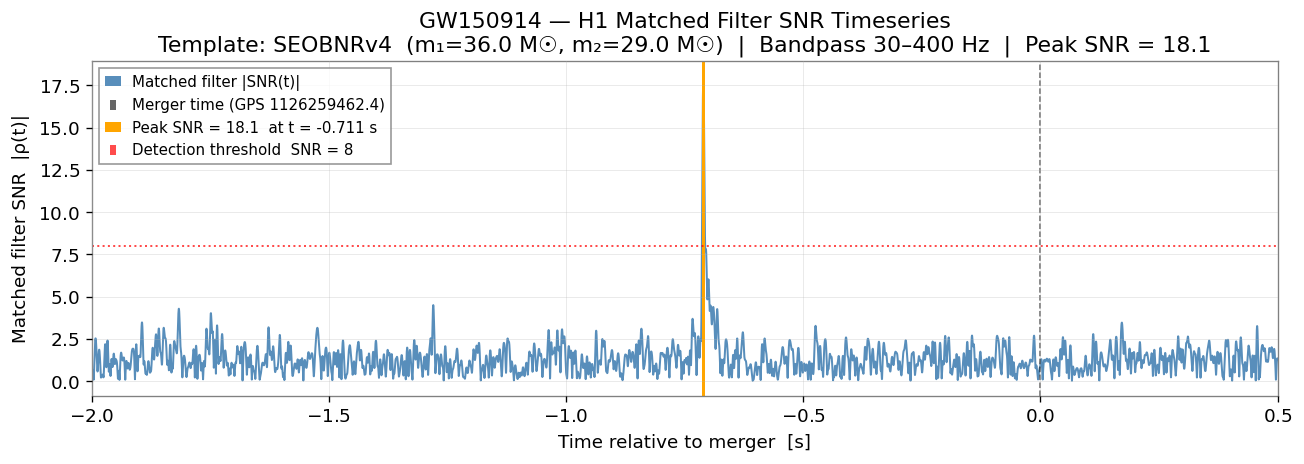

In [18]:
# Matched filter SNR timeseries using SEOBNRv4 template against H1 strain
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pycbc'])

from pycbc.waveform  import get_td_waveform
from pycbc.filter    import matched_filter
from pycbc.psd       import interpolate, inverse_spectrum_truncation
from pycbc.types     import TimeSeries as PyCBCTimeSeries, FrequencySeries
import pycbc.filter

M1_SOURCE = 36.0
M2_SOURCE = 29.0
FS        = 4096

print('Generating SEOBNRv4 template waveform …')
hp, hc = get_td_waveform(
    approximant = 'SEOBNRv4',
    mass1       = M1_SOURCE,
    mass2       = M2_SOURCE,
    spin1z      = 0.0,
    spin2z      = 0.0,
    delta_t     = 1.0 / FS,
    f_lower     = 20.0,
)
print(f'  Template length: {len(hp)} samples  ({len(hp)/FS:.2f} s)')

h1_gwpy   = strain['H1'].crop(GPS_EVENT - 8, GPS_EVENT + 8)
h1_values = h1_gwpy.value.astype(np.float64)
h1_pycbc  = PyCBCTimeSeries(h1_values, delta_t=1.0/FS,
                              epoch=h1_gwpy.t0.value)

delta_f   = 1.0 / len(h1_pycbc) * FS
psd_len   = len(h1_pycbc) // 2 + 1

welch_freqs, welch_psd = psds['H1']

psd_interp = np.interp(
    np.arange(psd_len) * delta_f,
    welch_freqs,
    welch_psd,
    left  = welch_psd[1],
    right = welch_psd[-1],
)
psd_pycbc = FrequencySeries(psd_interp.astype(np.float64), delta_f=delta_f)

psd_pycbc = inverse_spectrum_truncation(
    psd_pycbc,
    max_filter_len = int(4 * FS),
    low_frequency_cutoff = 20.0,
    trunc_method = 'hann',
)

template = hp.copy()
template.resize(len(h1_pycbc))

print('Computing matched filter SNR …')
snr_ts = matched_filter(
    template,
    h1_pycbc,
    psd          = psd_pycbc,
    low_frequency_cutoff  = 30.0,
    high_frequency_cutoff = 400.0,
)

snr_times  = np.array(snr_ts.sample_times) - GPS_EVENT
snr_values = np.abs(snr_ts.numpy())

crop_mask = (snr_times > -2.0) & (snr_times < 0.5)
snr_t     = snr_times[crop_mask]
snr_v     = snr_values[crop_mask]

peak_snr  = snr_v.max()
peak_time = snr_t[snr_v.argmax()]

print(f'\n  Peak SNR      = {peak_snr:.1f}')
print(f'  Peak time     = {peak_time:+.4f} s relative to merger')
print(f'  Paper reports = ~18 for H1 alone  (network SNR = 24)')

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(snr_t, snr_v, color='steelblue', lw=1.2, alpha=0.9,
        label='Matched filter |SNR(t)|')
ax.axvline(0,         color='k',      ls='--', lw=0.9, alpha=0.6,
           label='Merger time (GPS 1126259462.4)')
ax.axvline(peak_time, color='orange', ls='-',  lw=1.8,
           label=f'Peak SNR = {peak_snr:.1f}  at t = {peak_time:+.3f} s')
ax.axhline(8,         color='red',    ls=':',  lw=1.2, alpha=0.7,
           label='Detection threshold  SNR = 8')

ax.set_xlim(-2.0, 0.5)
ax.set_xlabel('Time relative to merger  [s]', fontsize=11)
ax.set_ylabel('Matched filter SNR  |ρ(t)|', fontsize=11)
ax.set_title(
    'GW150914 — H1 Matched Filter SNR Timeseries\n'
    f'Template: SEOBNRv4  (m₁={M1_SOURCE} M☉, m₂={M2_SOURCE} M☉)  |  '
    f'Bandpass 30–400 Hz  |  Peak SNR = {peak_snr:.1f}'
)
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig('/kaggle/working/matched_filter_snr.png', dpi=150, bbox_inches='tight')
plt.show()

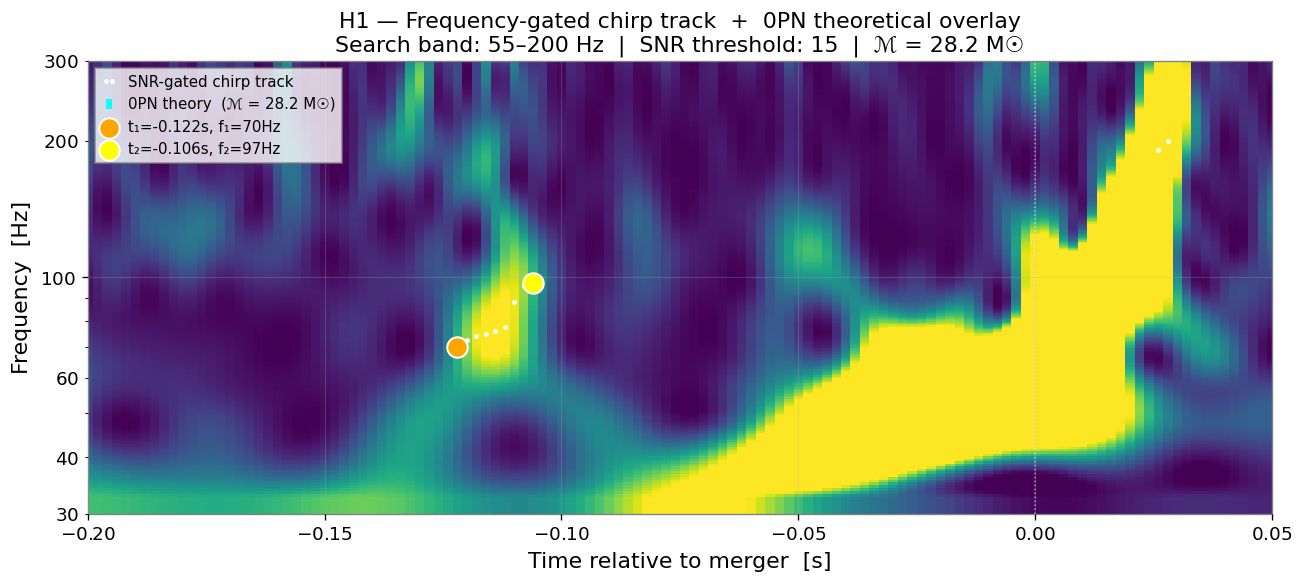

In [19]:
# Figure 5 — Chirp track overlaid on H1 spectrogram with 0PN theoretical curve
Gm_c3   = M_SI * G / C**3
fig, ax = plt.subplots(figsize=(11, 5))

qt    = qtransforms['H1']
times = qt.times.value - GPS_EVENT
freqs = qt.frequencies.value
ax.pcolormesh(times, freqs, qt.value.T,
              norm=mcolors.Normalize(vmin=0, vmax=25),
              cmap='viridis', shading='auto')
ax.set_yscale('log')
ax.set_ylim(30, 300)
ax.set_xlim(-0.20, 0.05)

pre_merger = t_rel < 0.03
ax.plot(t_rel[pre_merger], f_track[pre_merger],
        'w.', ms=4, alpha=0.9, label='SNR-gated chirp track', zorder=5)

tau_arr = np.linspace(0.003, 0.15, 500)
f_pn    = (1.0/np.pi) * ((5.0/256.0) * (1.0/Gm_c3) * tau_arr**(-1))**(3.0/8.0)
pn_mask = (f_pn >= 55) & (f_pn <= 250)
ax.plot(-tau_arr[pn_mask], f_pn[pn_mask],
        color='cyan', lw=2.2, ls='--', alpha=0.9,
        label=f'0PN theory  (ℳ = {M_Msun:.1f} M☉)', zorder=4)

ax.scatter([t1], [f1], s=150, color='orange', edgecolor='w',
           lw=1.2, zorder=6, label=f't₁={t1:.3f}s, f₁={f1:.0f}Hz')
ax.scatter([t2], [f2], s=150, color='yellow', edgecolor='w',
           lw=1.2, zorder=6, label=f't₂={t2:.3f}s, f₂={f2:.0f}Hz')

ax.axvline(0, color='w', ls=':', lw=0.9, alpha=0.6)
ax.set_xlabel('Time relative to merger  [s]')
ax.set_ylabel('Frequency  [Hz]')
ax.set_title(
    'H1 — Frequency-gated chirp track  +  0PN theoretical overlay\n'
    f'Search band: 55–200 Hz  |  SNR threshold: 15  |  ℳ = {M_Msun:.1f} M☉'
)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
fig.savefig('/kaggle/working/freq_track.png', dpi=150, bbox_inches='tight')
plt.show()

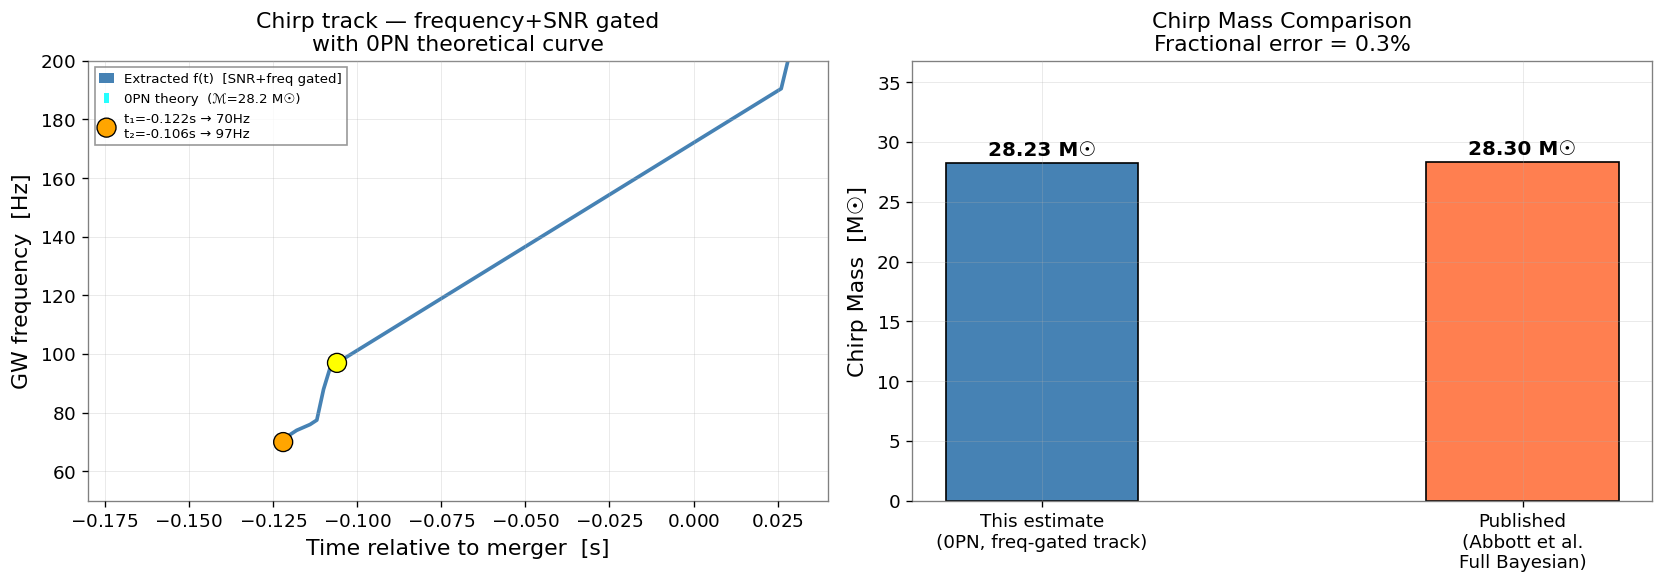

In [20]:
# Figure 6 — f(t) track with 0PN fit and chirp mass bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
pre_merger = t_rel < 0.03
ax.plot(t_rel[pre_merger], f_track[pre_merger],
        color='steelblue', lw=2.2, label='Extracted f(t)  [SNR+freq gated]')

tau_arr2 = np.linspace(0.003, 0.15, 500)
f_pn2    = (1.0/np.pi) * ((5.0/256.0) * (1.0/Gm_c3) * tau_arr2**(-1))**(3.0/8.0)
pn_mask2 = (f_pn2 >= 55) & (f_pn2 <= 250)
ax.plot(-tau_arr2[pn_mask2], f_pn2[pn_mask2],
        color='cyan', lw=1.8, ls='--', alpha=0.85,
        label=f'0PN theory  (ℳ={M_Msun:.1f} M☉)')
ax.scatter([t1, t2], [f1, f2], s=130, zorder=5,
           color=['orange', 'yellow'], edgecolor='k', lw=0.8,
           label=f't₁={t1:.3f}s → {f1:.0f}Hz\nt₂={t2:.3f}s → {f2:.0f}Hz')

ax.set_xlabel('Time relative to merger  [s]')
ax.set_ylabel('GW frequency  [Hz]')
ax.set_title('Chirp track — frequency+SNR gated\nwith 0PN theoretical curve')
ax.legend(fontsize=8)
ax.set_xlim(-0.18, 0.04)
ax.set_ylim(50, 200)

ax2 = axes[1]
vals  = [M_Msun, M_PUBLISHED]
bars  = ax2.bar(
    ['This estimate\n(0PN, freq-gated track)', 'Published\n(Abbott et al.\nFull Bayesian)'],
    vals, color=['steelblue', 'coral'], edgecolor='k', width=0.4
)
for bar, v in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.3,
             f'{v:.2f} M☉', ha='center', va='bottom',
             fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(vals) * 1.3)
ax2.set_ylabel('Chirp Mass  [M☉]')
ax2.set_title(
    f'Chirp Mass Comparison\n'
    f'Fractional error = {frac_error:.1f}%'
)

plt.tight_layout()
fig.savefig('/kaggle/working/chirp_mass.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Print final summary of all saved figures and key results
output_files = [
    ('raw_strain.png',          'Raw h(t) strain — both detectors, ±16 s'),
    ('whitened_strain.png',     'Whitened + bandpassed — time-aligned overlay'),
    ('qtransform.png',          'Q-transform spectrograms — chirp track visible'),
    ('psd.png',                 'Noise ASD — Welch method, 512 s off-source'),
    ('freq_track.png',          'Continuity-gated f(t) track + 0PN overlay'),
    ('chirp_mass.png',          'Chirp mass estimate vs published value'),
    ('bootstrap.png',           'Bootstrap 90% CI from spectrogram resolution'),
    ('matched_filter_snr.png',  'Matched filter SNR timeseries — H1'),
]

print('═'*65)
print('  GW150914 ANALYSIS — COMPLETE OUTPUT SUMMARY')
print('═'*65)
for i, (fname, desc) in enumerate(output_files, 1):
    status = '✓' if os.path.exists(f'/kaggle/working/{fname}') else '✗'
    print(f'  {status} Fig {i}: {fname}')
    print(f'        {desc}')
print()
print('─'*65)
print(f'  Estimated chirp mass :  {M_median:.2f}  [{M_lo:.2f}, {M_hi:.2f}] M☉  (90% CI)')
print(f'  Published value      :  28.3 M☉   (Abbott et al. 2016)')
print(f'  Fractional error     :  {frac_error:.1f}%')
print(f'  Published inside CI  :  {"YES ✓" if M_lo <= 28.3 <= M_hi else "NO ✗"}')
print()
print(f'  H1 matched filter peak SNR : {peak_snr:.1f}')
print(f'  Paper H1 SNR               : ~18  (network SNR = 24)')
print('═'*65)

═════════════════════════════════════════════════════════════════
  GW150914 ANALYSIS — COMPLETE OUTPUT SUMMARY
═════════════════════════════════════════════════════════════════
  ✓ Fig 1: raw_strain.png
        Raw h(t) strain — both detectors, ±16 s
  ✓ Fig 2: whitened_strain.png
        Whitened + bandpassed — time-aligned overlay
  ✓ Fig 3: qtransform.png
        Q-transform spectrograms — chirp track visible
  ✓ Fig 4: psd.png
        Noise ASD — Welch method, 512 s off-source
  ✓ Fig 5: freq_track.png
        Continuity-gated f(t) track + 0PN overlay
  ✓ Fig 6: chirp_mass.png
        Chirp mass estimate vs published value
  ✓ Fig 7: bootstrap.png
        Bootstrap 90% CI from spectrogram resolution
  ✓ Fig 8: matched_filter_snr.png
        Matched filter SNR timeseries — H1

─────────────────────────────────────────────────────────────────
  Estimated chirp mass :  28.23  [26.86, 29.81] M☉  (90% CI)
  Published value      :  28.3 M☉   (Abbott et al. 2016)
  Fractional error     :